# Problem and Objective Definition
## Telcom Customer Churn
- Predict behavior to retain customers.
- This is a classification problem, whether the customer will stay or not
- The target variable is ```churn``` tells whether customer stayed or not
- A sucessful model should have a high accuracy score

# Data Understanding and Cleaning

### Importing dependancies

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression

### Understanding data

In [2]:
df = pd.read_csv('telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [4]:
df.shape

(7043, 21)

- the data has 7043 entries(rows) and 21 features(columns)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


- In the data all columns are of data type object except for SeniorCitizen and tenure which are int64 and MonthlyCharges which is float64

In [6]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

- The target feature has ```No & Yes``` values to show which customer retained relation which did not
    - No: 5174: means they didn't churn, the customer is still active and paying for services
    - Yes: 1869: means they churned
- The target feature is bias there are way less churned customers than not churned

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Features and Meanings
1. ```customerID```: Unique ID given to a customer by the company
2. ```gender```: gender of the customer male or female
3. ```SeniorCitizen```: whether a customer is a senior citizen or not
4. ```Partner```: whether the customer has a partner or not
5. ```Dependents```: whether a customer has dependants or not
6. ```tenure```: No of months the customer has stayed with the company
7. ```PhoneService```: Whether the customer has a phone service or not
8. ```MultipleLines```: whether the customer has multiple lines or not
9. ```InternetService```: customers ISP
10. ```OnlineSecurity```: whether customer has online security or not
11. ```OnlineBackup```: has backup or not
12. ```DeviceProtection```: has device preotection or not
13. ```TechSupport```: has tech support or not
14. ```StreamingTV```: has streaming tv or not
15. ```StreamingMovies```: has streaming movies or not
16. ```Contract```: term of customer
17. ```PaperlessBilling```: has paperless billing or not
18. ```PaymentMethod```: payment method
19. ```MonthlyCharges```: amount customer pays monthly
20. ```TotalCharges```: total amount charged to the customer
21. ```Churn```: whether they are still paying for services or not

In [8]:
for i in df.columns:
    if i != 'Churn':
        print(f'*****{i}****')
        print(df[i].unique())
    print('')

*****customerID****
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

*****gender****
['Female' 'Male']

*****SeniorCitizen****
[0 1]

*****Partner****
['Yes' 'No']

*****Dependents****
['No' 'Yes']

*****tenure****
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

*****PhoneService****
['No' 'Yes']

*****MultipleLines****
['No phone service' 'No' 'Yes']

*****InternetService****
['DSL' 'Fiber optic' 'No']

*****OnlineSecurity****
['No' 'Yes' 'No internet service']

*****OnlineBackup****
['Yes' 'No' 'No internet service']

*****DeviceProtection****
['No' 'Yes' 'No internet service']

*****TechSupport****
['No' 'Yes' 'No internet service']

*****StreamingTV****
['No' 'Yes' 'No internet service']

*****StreamingMovies****
['No' 'Yes' 'No internet service']

*****Contract****
['Mon

- Most of the features have categories which can be encoded

### Data Cleaning

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

- The data has no null values

In [10]:
df.duplicated().sum()

np.int64(0)

- The data has no duplicates

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

- converting TotalCharges column to numeric

In [12]:
df['TotalCharges'].dtype

dtype('float64')

In [13]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

- since the missing rows are a few remove them

In [14]:
df = df.dropna(subset=['TotalCharges'])
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# EDA
- core question ```What customer characteristics and services increase the likelihood of churn?```

### Target Variable analysis

In [15]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaperlessBilling', 'PaymentMethod']

In [16]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

- There is an imbalnce between churned and non churned customers

### Target Vs Feature analysis

1. tenure

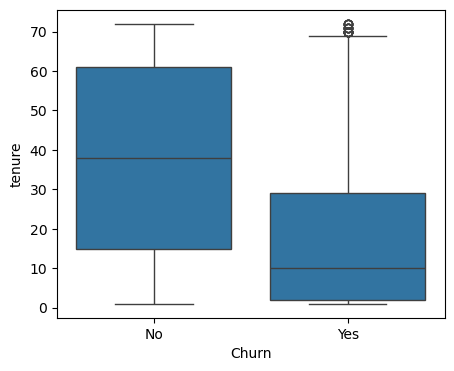

In [17]:
plt.figure(figsize=(5,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

- The customers who churned mostly  had less than 30 months of tenure with telco.
- The customers who did not churn mostly are between 15-60 months of tenure of telco

2. MonthlyCharges

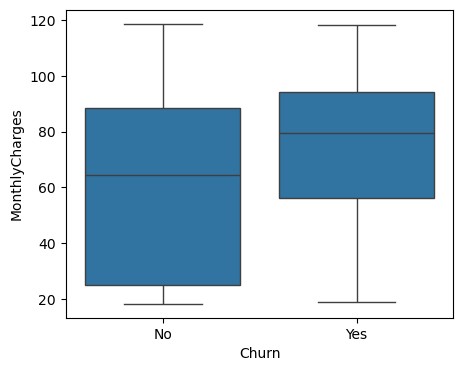

In [18]:
plt.figure(figsize=(5,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

3. TotalCharges

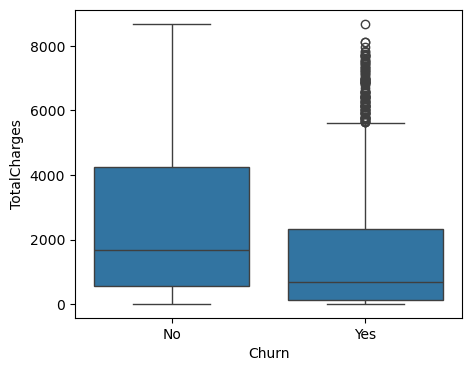

In [19]:
plt.figure(figsize=(5,4))
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.show()

4. Gender

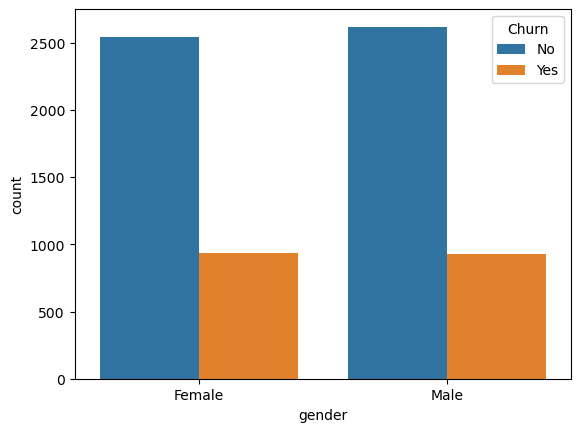

In [20]:
sns.countplot(data=df, x='gender', hue='Churn')
plt.show()

- The number of females and males who churned and did not is almost same

5. SeniorCitizen

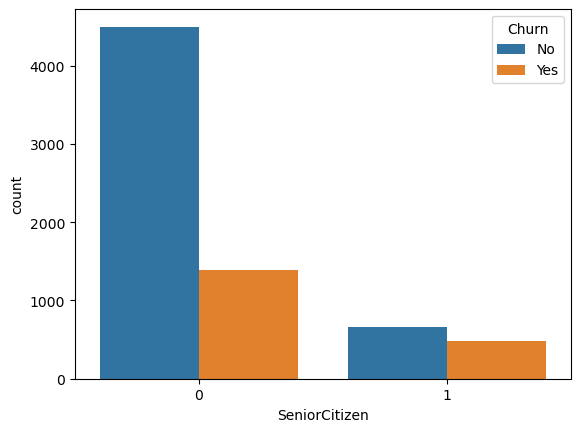

In [21]:
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')
plt.show()

- Senior citizens who churned were less compared to non senior citizens who churned

6. Partner

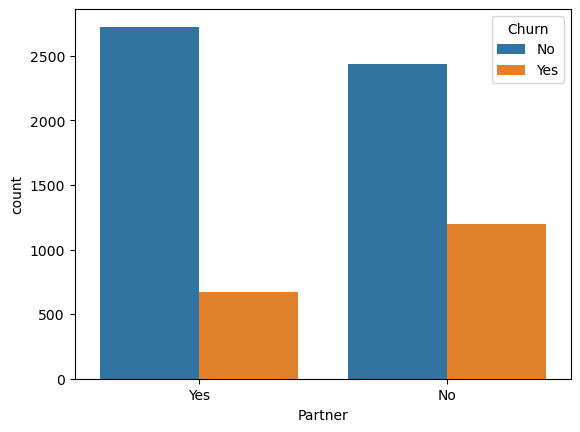

In [22]:
sns.countplot(data=df, hue='Churn', x='Partner')
plt.show()

- Cunstomers without patners churned more that those with partners

7. Dependents

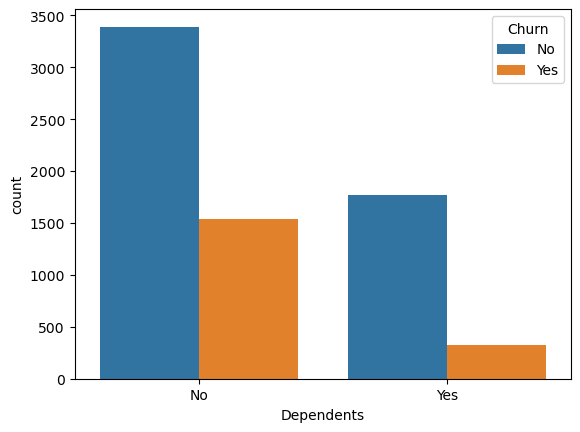

In [23]:
sns.countplot(data=df, hue='Churn', x='Dependents')
plt.show()

- customers without dependents churned more than those with.

8. PhoneService

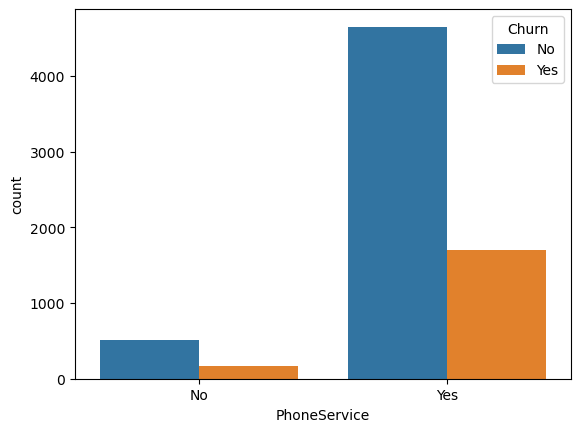

In [24]:
sns.countplot(data=df, hue='Churn', x='PhoneService')
plt.show()

- Customers with phone service are the ones who churned more

9. MultipleLines

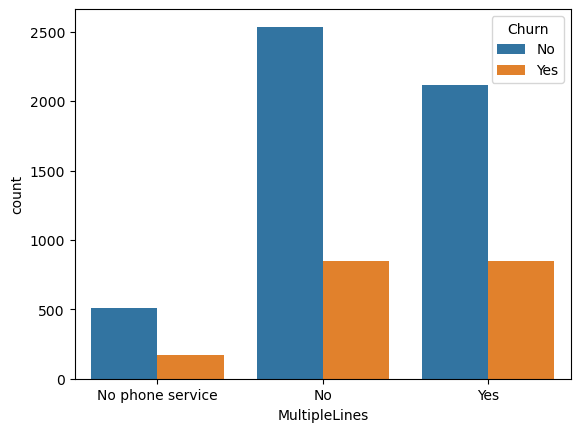

In [25]:
sns.countplot(data=df, hue='Churn', x='MultipleLines')
plt.show()

- Customers with and without multiple lines churned more than those without phone service

10. InternetService

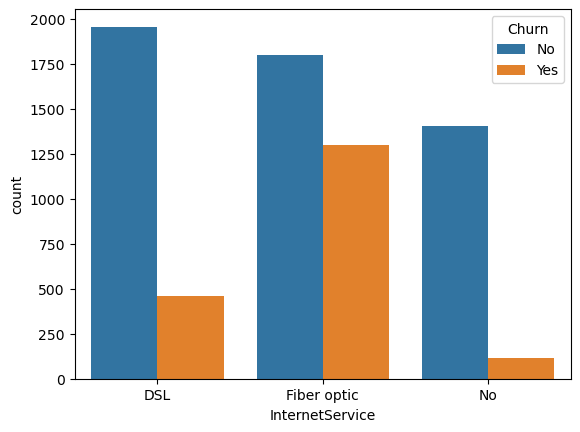

In [26]:
sns.countplot(data=df, hue='Churn', x='InternetService')
plt.show()

- Customers with Fibre optic Internet Service churned more than those with DSL and without Intenet service

11. OnlineSecurity

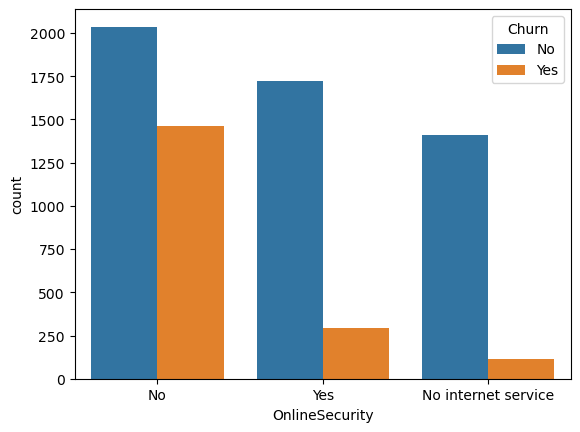

In [27]:
sns.countplot(data=df, hue='Churn', x='OnlineSecurity')
plt.show()

- customers with no online security churned more than those with online security and no internet service

12. OnlineBackup

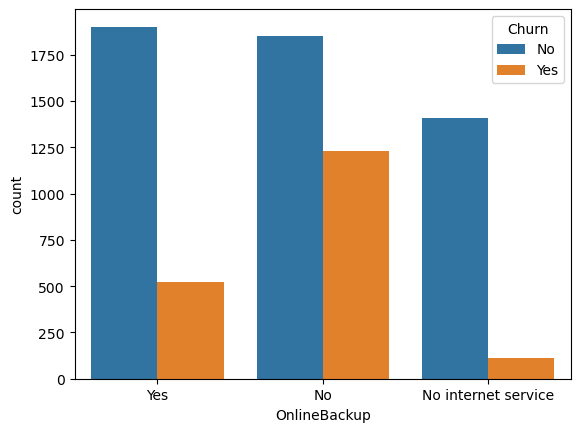

In [28]:
sns.countplot(data=df, hue='Churn', x='OnlineBackup')
plt.show()

- Customers with no online backup churned more than those with and with no internet service

13. DeviceProtection

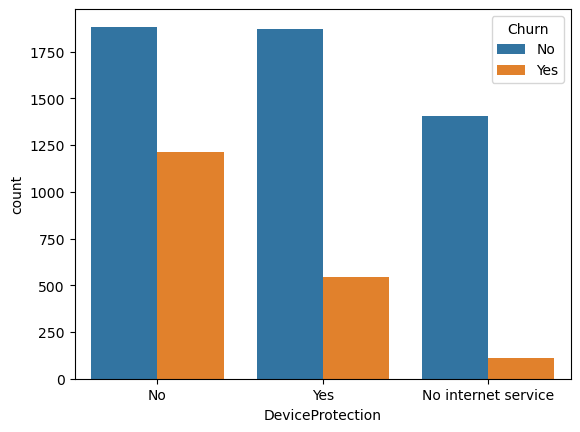

In [29]:
sns.countplot(data=df, hue='Churn', x='DeviceProtection')
plt.show()

- Customers with no device protection churned more that those with and with no internet service

14. TechSupport

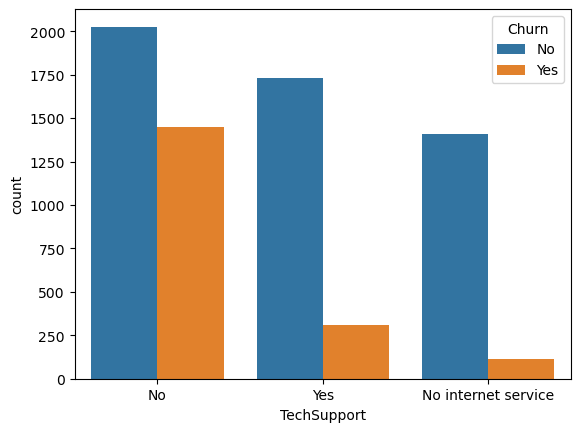

In [30]:
sns.countplot(data=df, hue='Churn', x='TechSupport')
plt.show()

- customers with no Tech Support churned more taht those with it and with no internet service

15. StreamingTV

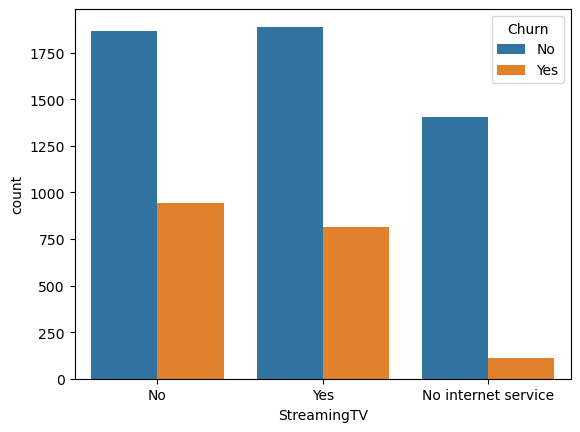

In [31]:
sns.countplot(data=df, hue='Churn', x='StreamingTV')
plt.show()

16. Contract

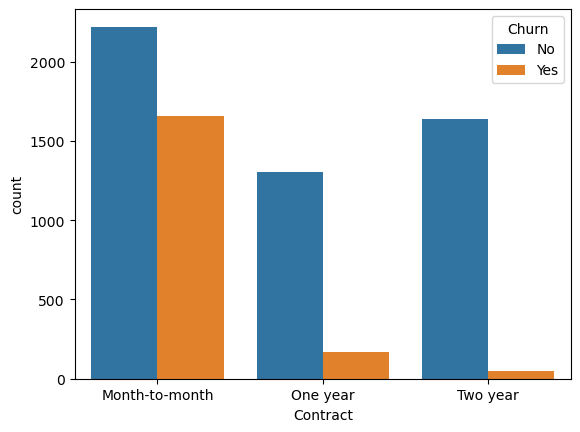

In [32]:
sns.countplot(data=df, hue='Churn', x='Contract')
plt.show()

- Customers with month-to-month contract churned more than the ones with one year and two year

17. PaperlessBilling

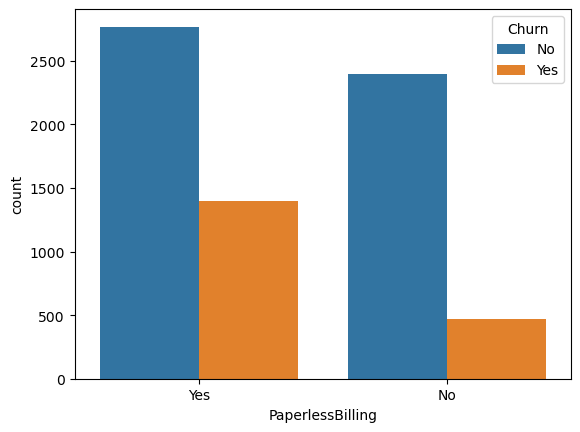

In [33]:
sns.countplot(data=df, hue='Churn', x='PaperlessBilling')
plt.show()

- Customers with paperless billing churned more that those without

18. PaymentMethod

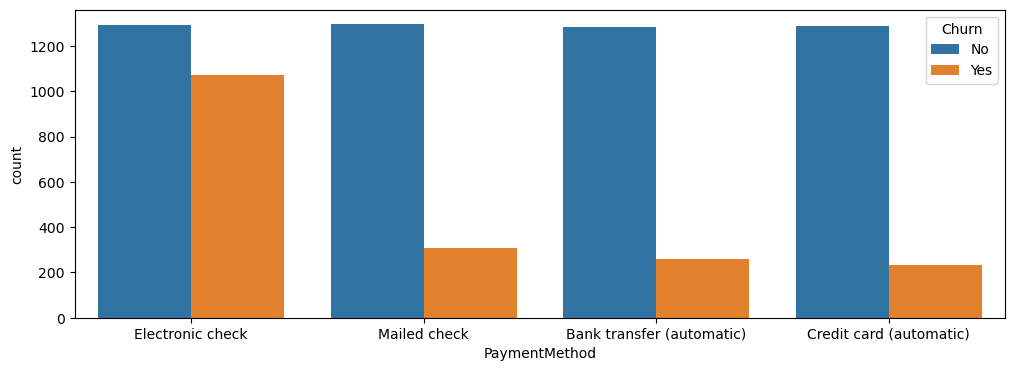

In [34]:
plt.figure(figsize=(12,4))
sns.countplot(data=df, hue='Churn', x='PaymentMethod')
plt.show()

- customers with electronic chack churned more than mailed check, bank transfer or credit card

19. StreamingMovies

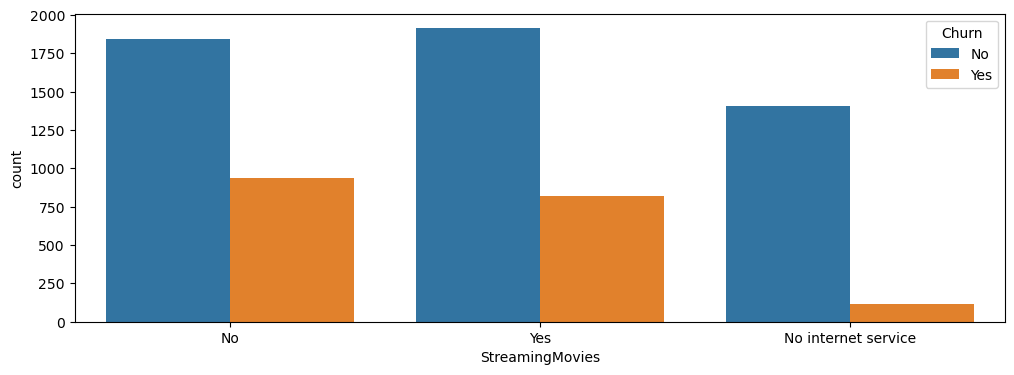

In [35]:
plt.figure(figsize=(12,4))
sns.countplot(data=df, hue='Churn', x='StreamingMovies')
plt.show()

- Customers who were streaming movies and those who were not churned almost same, the ones with no internet churned least

# Feature Engineering

### Encode target variable

In [36]:
df.loc[:,'Churn'] = df['Churn'].map({'Yes':1, 'No': 0})
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0


### Tenure based feature

In [37]:
df['is_early_tenure'] = (df['tenure'] < 30).astype(int)

- Most of the churned customers had 30 months or less in the tenure

In [38]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 30, 60, df['tenure'].max()],
    labels=['new', 'early', 'mid', 'loyal']
)

### Household features

In [39]:
df.loc[:, 'Partner'] = df['Partner'].map({'Yes':1, 'No': 0})
df.loc[:, 'Dependents'] = df['Dependents'].map({'Yes':1, 'No': 0})

In [40]:
df['household_score'] = df['Partner'] + df['Dependents']

- gives score to a household
    - 0: unstable
    - 1: semi-stable
    - 2: stable

In [41]:
df['is_unstable_household'] = (df['household_score'] == 0).astype(int)

### Phone & Line features

In [42]:
# Encode PhoneService
df.loc[:, 'PhoneService'] = df['PhoneService'].map({'Yes':1, 'No':0})

In [43]:
# Phone only customers
df['phone_only_customer'] = (
    (df['PhoneService'] == 1) &
    (df['InternetService'] == 'No')
).astype(int)

In [44]:
# Multiple lines flag
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
df.loc[:, 'MultipleLines'] = df['MultipleLines'].map({'Yes':1, 'No':0})

### Internet Service and Protection Bundle

In [45]:
protection_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport'
]

for col in protection_cols:
    df[col] = df[col].replace('No internet service', 'No')
    df.loc[:, col] = df[col].map({'Yes':1, 'No':0})

In [46]:
df['protection_count'] = df[protection_cols].sum(axis=1)

In [47]:
df['fibre_low_protection'] = (
    (df['InternetService'] == 'Fiber optic') &
    (df['protection_count'] <= 1)
).astype(int)

### Contact features

In [48]:
# Contract Encoding
df['contract_length'] = df['Contract'].map({'Month-to-month':0, 'One year':1, 'Two year':2})

In [49]:
# Monthly contract
df['is_monthly_contract'] = (df['contract_length'] == 0).astype(int)

### Billing

In [50]:
## Encode paperless billing 
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})

In [51]:
## High friction payment method
df['is_electronic_check'] = (
    df['PaymentMethod'] == 'Electronic check'
).astype(int)

In [52]:
## Billing risk
df['billing_risk'] = df['PaperlessBilling'] * df['is_electronic_check']

### charges value based features

In [53]:
## Avg monthly value
df['avg_monthly_value'] = df['TotalCharges'] / df['tenure']

In [54]:
df['avg_monthly_value'] = df['avg_monthly_value'].replace([np.inf, -np.inf], 0)

### Others

In [55]:
categorical_cols = [
    'InternetService',
    'tenure_group',
    'gender'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [56]:
drop_cols = [
    'customerID',
    'Contract',
    'PaymentMethod',
    'StreamingTV',
    'StreamingMovies'
]

df_featured = df.drop(columns=drop_cols, errors='ignore')

### Sanity check

In [57]:
df_featured.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,is_monthly_contract,is_electronic_check,billing_risk,avg_monthly_value,InternetService_Fiber optic,InternetService_No,tenure_group_early,tenure_group_mid,tenure_group_loyal,gender_Male
0,0,1,0,1,0,0,0,1,0,0,...,1,1,1,29.850000,False,False,False,False,False,False
1,0,0,0,34,1,0,1,0,1,0,...,0,0,0,55.573529,False,False,False,True,False,True
2,0,0,0,2,1,0,1,1,0,0,...,1,0,0,54.075000,False,False,False,False,False,True
3,0,0,0,45,0,0,1,0,1,1,...,0,0,0,40.905556,False,False,False,True,False,True
4,0,0,0,2,1,0,0,0,0,0,...,1,1,1,75.825000,True,False,False,False,False,False


In [58]:
df_featured.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SeniorCitizen                7032 non-null   int64  
 1   Partner                      7032 non-null   object 
 2   Dependents                   7032 non-null   object 
 3   tenure                       7032 non-null   int64  
 4   PhoneService                 7032 non-null   object 
 5   MultipleLines                7032 non-null   object 
 6   OnlineSecurity               7032 non-null   object 
 7   OnlineBackup                 7032 non-null   object 
 8   DeviceProtection             7032 non-null   object 
 9   TechSupport                  7032 non-null   object 
 10  PaperlessBilling             7032 non-null   int64  
 11  MonthlyCharges               7032 non-null   float64
 12  TotalCharges                 7032 non-null   float64
 13  Churn                  

# Baseline Model

In [59]:
X = df_featured.drop('Churn', axis=1)
y = df_featured['Churn']
y = y.astype(int)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, stratify=y, random_state=42)

In [60]:
## Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
y_train.unique()

array([0, 1])

In [62]:
## Model
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

# model fit
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

In [63]:
## Evaluations

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.7242359630419332
Precision: 0.48841059602649006
Recall: 0.7887700534759359
F1: 0.6032719836400818
ROC AUC: 0.8360351709107475


In [64]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[724, 309],
       [ 79, 295]])

In [65]:
### Interpret Logistic coefficient

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df


,Feature,Coefficient
11,MonthlyCharges,0.459471
23,avg_monthly_value,0.283481
12,TotalCharges,0.268174
24,InternetService_Fiber optic,0.156512
21,is_electronic_check,0.130104
10,PaperlessBilling,0.107088
28,tenure_group_loyal,0.097172
5,MultipleLines,0.093432
0,SeniorCitizen,0.079335
22,billing_risk,0.054751


# Complex Model

In [70]:
## SPlitting the data
X = df_featured.drop('Churn', axis=1)
y = df_featured['Churn']
y = y.astype(int)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [77]:
## Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Model creation
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)

# Training model
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test_scaled)[:, 1]

/home/devtech/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [79]:
## Evaluations

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.7839374555792467
Precision: 0.6190476190476191
Recall: 0.48663101604278075
F1: 0.5449101796407185
ROC AUC: 0.8004345890428687


In [80]:
df_featured.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'is_early_tenure', 'household_score', 'is_unstable_household',
       'phone_only_customer', 'protection_count', 'fibre_low_protection',
       'contract_length', 'is_monthly_contract', 'is_electronic_check',
       'billing_risk', 'avg_monthly_value', 'InternetService_Fiber optic',
       'InternetService_No', 'tenure_group_early', 'tenure_group_mid',
       'tenure_group_loyal', 'gender_Male'],
      dtype='object')

### Save model

In [81]:
import joblib

joblib.dump(rf, 'random_forest_churn.pkl')
joblib.dump(model, 'Logistic_regression_churn.pkl')

['Logistic_regression_churn.pkl']